In [1]:
import os
os.chdir('../../../../..')

In [2]:
from src.datasets import MaterialsProject

In [3]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids

from src.helper_functions import create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster

In [4]:
mp = MaterialsProject(limit=5000, sampling_strategy="stratified", stratify_on=["band_gap", "energy_above_hull"], add_soap=True)
df = mp.load()

2026-04-21 09:25:21.922 | INFO     | src.datasets:load:1317 - Loading full cached Parquet data from data/Materials Project/materials.parquet...
2026-04-21 09:25:22.671 | INFO     | src.datasets:_add_descriptors:1666 - Ignoring output_tag=sample_n6000_seed40_stratified since descriptors are attached directly to dataframe.
2026-04-21 09:25:22.672 | INFO     | src.datasets:_add_descriptors:1670 - Extracting unique elements from formulas...
2026-04-21 09:25:35.689 | INFO     | src.datasets:_add_descriptors:1679 - Found 85 unique elements.
2026-04-21 09:25:35.701 | INFO     | src.datasets:_add_descriptors:1724 - Computing SOAP chunk 0 (0 to 1000)...
2026-04-21 09:25:37.614 | INFO     | src.datasets:_add_descriptors:1724 - Computing SOAP chunk 1 (1000 to 2000)...
2026-04-21 09:25:39.224 | INFO     | src.datasets:_add_descriptors:1724 - Computing SOAP chunk 2 (2000 to 3000)...
2026-04-21 09:25:40.873 | INFO     | src.datasets:_add_descriptors:1724 - Computing SOAP chunk 3 (3000 to 4000)...
20

In [5]:
print(np.array(df["soap_embedding"].to_list()[0]).shape)

(252,)


In [6]:
dist_type = "soap_kernel"
dist_matrix = mp.get_distance_matrix(
    descriptor="soap",
    dist_type=dist_type,
    force_calculate=True,
    pca_variance=99.9,
)

2026-04-21 09:25:51.601 | INFO     | src.datasets:get_distance_matrix:1929 - Applying PCA to retain 99.90% of variance.
2026-04-21 09:25:51.702 | INFO     | src.datasets:get_distance_matrix:1938 - PCA reduced 'soap' dimensions from 252 to 8
2026-04-21 09:25:51.727 | INFO     | src.datasets:get_distance_matrix:1949 - Calculating distance matrix for soap using soap_kernel distance.
2026-04-21 09:25:51.955 | SUCCESS  | src.distance:_compute_and_save:79 - Saved distance matrix to data/Materials Project/dist_soap_soap_kernel_pca0.9990000000000001.npy


# Hierarchical Clustering on Distance Matrix

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [45.0, 45.0, 55.0, 55.0],
  [35.0, 35.0, 50.0, 50.0],
  [12.5, 12.5, 42.5, 42.5],
  [85.0, 85.0, 95.0, 95.0],
  [75.0, 75.0, 90.0, 90.0],
  [65.0, 65.0, 82.5, 82.5],
  [27.5, 27.5, 73.75, 73.75],
  [115.0, 115.0, 125.0, 125.0],
  [105.0, 105.0, 120.0, 120.0],
  [155.0, 155.0, 165.0, 165.0],
  [145.0, 145.0, 160.0, 160.0],
  [135.0, 135.0, 152.5, 152.5],
  [112.5, 112.5, 143.75, 143.75],
  [175.0, 175.0, 185.0, 185.0],
  [195.0, 195.0, 205.0, 205.0],
  [225.0, 225.0, 235.0, 235.0],
  [215.0, 215.0, 230.0, 230.0],
  [200.0, 200.0, 222.5, 222.5],
  [180.0, 180.0, 211.25, 211.25],
  [245.0, 245.0, 255.0, 255.0],
  [265.0, 265.0, 275.0, 275.0],
  [285.0, 285.0, 295.0, 295.0],
  [270.0, 270.0, 290.0, 290.0],
  [250.0, 250.0, 280.0, 280.0],
  [195.625, 195.625, 265.0, 265.0],
  [128.125, 128.125, 230.3125, 230.3125],
  [50.625, 50.625, 179.21875, 179.21875]],
 'dcoord': [[0.0,
   np.float64(1.2621773481369019),
   np.float64(1.

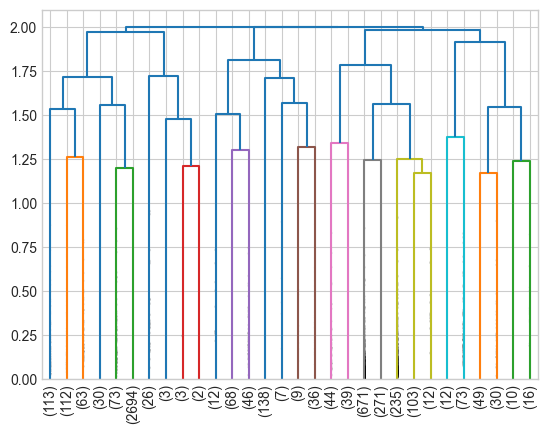

In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
condensed_dist = squareform(dist_matrix)
Z = linkage(condensed_dist, method='complete')
dendrogram(
    Z,
    truncate_mode='lastp',  # show only the last p merged clusters
    p=30,                   # show the last 30 merges
    leaf_rotation=90.,
    leaf_font_size=10.,
    show_contracted=True
)

In [16]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=4, linkage='complete')
labels_hier = model_hier.fit_predict(dist_matrix)
print(np.unique(labels_hier, return_counts=True))
df = df.with_columns(labels_hier=labels_hier)

(array([0, 1, 2, 3]), array([3119,  190,  316, 1375]))


In [17]:
d = average_numeric_by_cluster(df, "labels_hier")

shape: (4, 19)
┌─────────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬───────────┐
│ labels_hier ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ pct_metal │
│ ---         ┆ ---   ┆ ---         ┆ ---             ┆ ---                       ┆ ---      ┆ ---     ┆ ---    ┆ ---    ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---      ┆ ---       ┆ ---               ┆ ---             ┆ ---             ┆ ---       │
│ i64         ┆ u32   ┆ f64         ┆ f64             ┆ f64                       ┆ f64      ┆ f64     ┆ f64    ┆ f64    ┆ f64     ┆ f64     ┆ f64     ┆ f64     ┆ f64      ┆ f64       ┆ f64               ┆ f64             ┆

In [18]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-21 09:30:44.690 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/materials_project/clustering/soap_kernel/soap/pca_hierarchical_projection.png


{'coords': array([[ 69.452576 ,  -5.534922 ],
        [ 74.658104 ,   4.7394447],
        [-43.155144 ,   2.4004843],
        ...,
        [-43.00159  ,   2.7514362],
        [-43.048145 ,   2.9704266],
        [-43.03756  ,   2.9792025]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/materials_project/clustering/soap_kernel/soap/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/soap_kernel/soap'),
 'clustering_method': 'hierarchical'}

In [19]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

# KMedoids

In [20]:
model_km = KMedoids(n_clusters=3, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)

(array([0, 1, 2], dtype=uint64), array([3222,  412, 1366]))


In [22]:
d = average_numeric_by_cluster(df, "labels_km")

shape: (3, 20)
┌───────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬─────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┐
│ labels_km ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma   ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ pct_metal │
│ ---       ┆ ---   ┆ ---         ┆ ---             ┆ ---                       ┆ ---      ┆ ---     ┆ ---    ┆ ---    ┆ ---     ┆ ---     ┆ ---     ┆ ---     ┆ ---      ┆ ---       ┆ ---               ┆ ---             ┆ ---             ┆ ---         ┆ ---       │
│ u64       ┆ u32   ┆ f64         ┆ f64             ┆ f64                       ┆ f64      ┆ f64     ┆ f64    ┆ f64    ┆ f64     ┆ f64     ┆ f64     ┆ f64     ┆ f64      ┆ f64       ┆ f64

In [23]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

In [24]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-21 09:32:36.323 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/materials_project/clustering/soap_kernel/soap/pca_kmedoids_projection.png


{'coords': array([[ 69.452576 ,  -5.534922 ],
        [ 74.658104 ,   4.7394447],
        [-43.155144 ,   2.4004843],
        ...,
        [-43.00159  ,   2.7514362],
        [-43.048145 ,   2.9704266],
        [-43.03756  ,   2.9792025]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/materials_project/clustering/soap_kernel/soap/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/soap_kernel/soap'),
 'clustering_method': 'kmedoids'}

# Spectral

In [25]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)

KeyboardInterrupt: 

In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [ ]:
average_numeric_by_cluster(df, "labels_spectral")

# DBSCAN

In [29]:
model_db = DBSCAN(
    eps=0.3,
    min_samples=4,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db,return_counts=True))

(array([-1,  0,  1,  2,  3]), array([ 118, 4868,    6,    5,    3]))


In [30]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: materials_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show materials_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'Materials Project - PCA Clustering'}, settings={'map': {'x': {'property': 'PC…

In [31]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="soap",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="materials_project",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-21 09:37:06.554 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/materials_project/clustering/soap_kernel/soap/pca_dbscan_projection.png


{'coords': array([[ 69.452576 ,  -5.534922 ],
        [ 74.658104 ,   4.7394447],
        [-43.155144 ,   2.4004843],
        ...,
        [-43.00159  ,   2.7514362],
        [-43.048145 ,   2.9704266],
        [-43.03756  ,   2.9792025]], shape=(5000, 2), dtype=float32),
 'figure_path': PosixPath('figures/materials_project/clustering/soap_kernel/soap/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/materials_project/clustering/soap_kernel/soap'),
 'clustering_method': 'dbscan'}

In [32]:
average_numeric_by_cluster(df, "labels_db")

shape: (5, 21)
┌───────────┬───────┬─────────────┬─────────────────┬───────────────────────────┬──────────┬─────────┬────────┬────────┬─────────┬─────────┬─────────┬──────────┬──────────┬───────────┬───────────────────┬─────────────────┬─────────────────┬─────────────┬───────────┬───────────┐
│ labels_db ┆ count ┆ max_en_diff ┆ energy_per_atom ┆ formation_energy_per_atom ┆ band_gap ┆ density ┆ a      ┆ b      ┆ c       ┆ alpha   ┆ beta    ┆ gamma    ┆ volume   ┆ num_sites ┆ energy_above_hull ┆ avg_bond_length ┆ max_bond_length ┆ labels_hier ┆ labels_km ┆ pct_metal │
│ ---       ┆ ---   ┆ ---         ┆ ---             ┆ ---                       ┆ ---      ┆ ---     ┆ ---    ┆ ---    ┆ ---     ┆ ---     ┆ ---     ┆ ---      ┆ ---      ┆ ---       ┆ ---               ┆ ---             ┆ ---             ┆ ---         ┆ ---       ┆ ---       │
│ i64       ┆ u32   ┆ f64         ┆ f64             ┆ f64                       ┆ f64      ┆ f64     ┆ f64    ┆ f64    ┆ f64     ┆ f64     ┆ f64    

labels_db,count,max_en_diff,energy_per_atom,formation_energy_per_atom,band_gap,density,a,b,c,alpha,beta,gamma,volume,num_sites,energy_above_hull,avg_bond_length,max_bond_length,labels_hier,labels_km,pct_metal
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-1,118,1.234661,-15.458874,-0.866376,0.230481,6.973755,6.663522,7.001346,8.461187,82.685253,81.920312,82.049848,301.918986,14.898305,0.077641,2.476598,2.695967,1.186441,0.779661,81.355932
0,4868,1.604304,-13.324036,-1.309281,0.658818,6.158337,6.820894,7.267726,9.33841,86.345652,87.077656,89.248749,424.717113,25.807108,0.083555,2.286458,2.577156,0.979458,0.624076,58.586689
1,6,0.45,-25.524066,-0.414512,0.459867,5.581028,3.395873,3.395873,37.486604,90.0,90.0,119.999998,375.058507,11.5,0.113716,2.612977,2.691969,3.0,1.0,16.666667
2,5,0.538,-29.013821,-0.370891,0.49036,6.53132,3.455198,3.455198,36.367924,90.0,90.0,120.000001,375.662175,11.8,0.084115,2.643534,2.703989,3.0,1.0,40.0
3,3,1.956667,-9.160613,-1.619175,0.531767,7.221272,5.89314,5.947332,11.037991,61.516184,61.489967,59.602254,210.042349,13.333333,0.177242,2.099915,2.367163,2.0,1.0,0.0


# KMeans on Raw Embeddings

In [ ]:
X_raw = np.array(df["soap_embedding"].to_list(), dtype=np.float32)
kmeans_raw = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans_raw = kmeans_raw.fit_predict(X_raw)
df = df.with_columns(labels_kmeans_raw=labels_kmeans_raw)

NameError: name 'np' is not defined

In [ ]:
create_chemiscope_viewer(df, X_raw, labels_kmeans_raw, 'PCA')

In [ ]:
average_numeric_by_cluster(df, "labels_kmeans_raw")